In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import trimesh

In [2]:
df = pd.read_pickle('./data.pkl')

In [3]:
# TPC boundaries (cm)
tpcMinX = -200
tpcMaxX = 200
tpcMinY = -200
tpcMaxY = 200
tpcMinZ = 0
tpcMaxZ = 500
tpcProjZFront = tpcMinZ

'''
# Fiducial volume boundaries (cm)
tpcMinX = -183.5
tpcMaxX = 183.5
tpcMinY = -185
tpcMaxY = 185
tpcMinZ = 40 # start of the fiducial volume, where 0 is the front face of the tpc
tpcMaxZ = 460
tpcProjZFront = 0
'''

# Beam center (cm)
beamCenterX = -74
beamCenterY = 0
beamCenterZ = 11000 # front face of the tpc, where 0 is the beam target

In [4]:
# Plot settings
colorTot = 'C3'; colorP = 'C0'; colorNP = 'C1'
ylimit = (0,)
xlimit=(0,)
erAlpha = 0.3

nbins = np.arange(0, 4.1, .2)
nbinsTPC = np.arange(0, 1.81, .2)

In [5]:
# front face normalization v3
tpcBox = trimesh.creation.box(extents=[(tpcMaxX-tpcMinX)/100, (tpcMaxY-tpcMinY)/100, (tpcMaxZ-tpcMinZ)/100])
tpcBox.apply_translation([beamCenterX/100, beamCenterY/100, 0])
norm_areas = np.array([])
for i in range(len(nbinsTPC)-1):
    rmin = ((beamCenterZ+tpcProjZFront)/100) * np.tan(nbinsTPC[i] * np.pi / 180)
    radius = ((beamCenterZ+tpcProjZFront)/100) * np.tan(nbinsTPC[i+1] * np.pi / 180)
    annulus = trimesh.creation.annulus(r_min=rmin, r_max=radius, height=1)
    vol_front3 = annulus.volume - annulus.difference(tpcBox).volume
    if vol_front3 < 1e-5:
        vol_front3 = 0
    norm_areas = np.append(norm_areas, vol_front3)
norm_areas

array([0.46021348, 1.38068529, 2.3012917 , 2.90156067, 3.15716035,
       2.66261935, 1.79451502, 1.0987741 , 0.24318045])

In [6]:
# back face normalization
tpcBox = trimesh.creation.box(extents=[(tpcMaxX-tpcMinX)/100, (tpcMaxY-tpcMinY)/100, (tpcMaxZ-tpcMinZ)/100])
tpcBox.apply_translation([beamCenterX/100, beamCenterY/100, 0])
norm_areas_back = np.array([])
for i in range(len(nbinsTPC)-1):
    rmin_back = ((beamCenterZ+tpcMaxZ)/100) * np.tan(nbinsTPC[i] * np.pi / 180)
    radius_back = ((beamCenterZ+tpcMaxZ)/100) * np.tan(nbinsTPC[i+1] * np.pi / 180)
    annulus_back = trimesh.creation.annulus(r_min=rmin_back, r_max=radius_back, height=1)
    vol_back = annulus_back.volume - annulus_back.difference(tpcBox).volume
    if vol_back < 1e-5:
        vol_back = 0
    norm_areas_back = np.append(norm_areas_back, vol_back)
norm_areas_back

array([0.50300192, 1.50905479, 2.51525478, 3.06264713, 3.38341498,
       2.39970571, 1.78209747, 0.76804313, 0.07677968])

In [7]:
# exact volume normalization
tpcBox = trimesh.creation.box(extents=[4, 4, 5])
tpcBox.apply_translation([-.74, 0, 2.5])
norm_vols = np.array([])
for i in range(len(nbinsTPC)-1):
    radius = 115 * np.tan(nbinsTPC[i+1] * np.pi / 180)
    cone = trimesh.creation.cone(radius=radius, height=115)
    vol = cone.volume - cone.difference(tpcBox).volume
    if i > 0:
        vol -= np.sum(norm_vols[0:i])
    if vol < 1e-5:
        vol = 0
    norm_vols = np.append(norm_vols, vol)
norm_vols

array([ 2.40724613,  7.22197472, 12.03740189, 14.91265475, 16.34991851,
       12.68422353,  8.99719651,  4.62961908,  0.75974863])

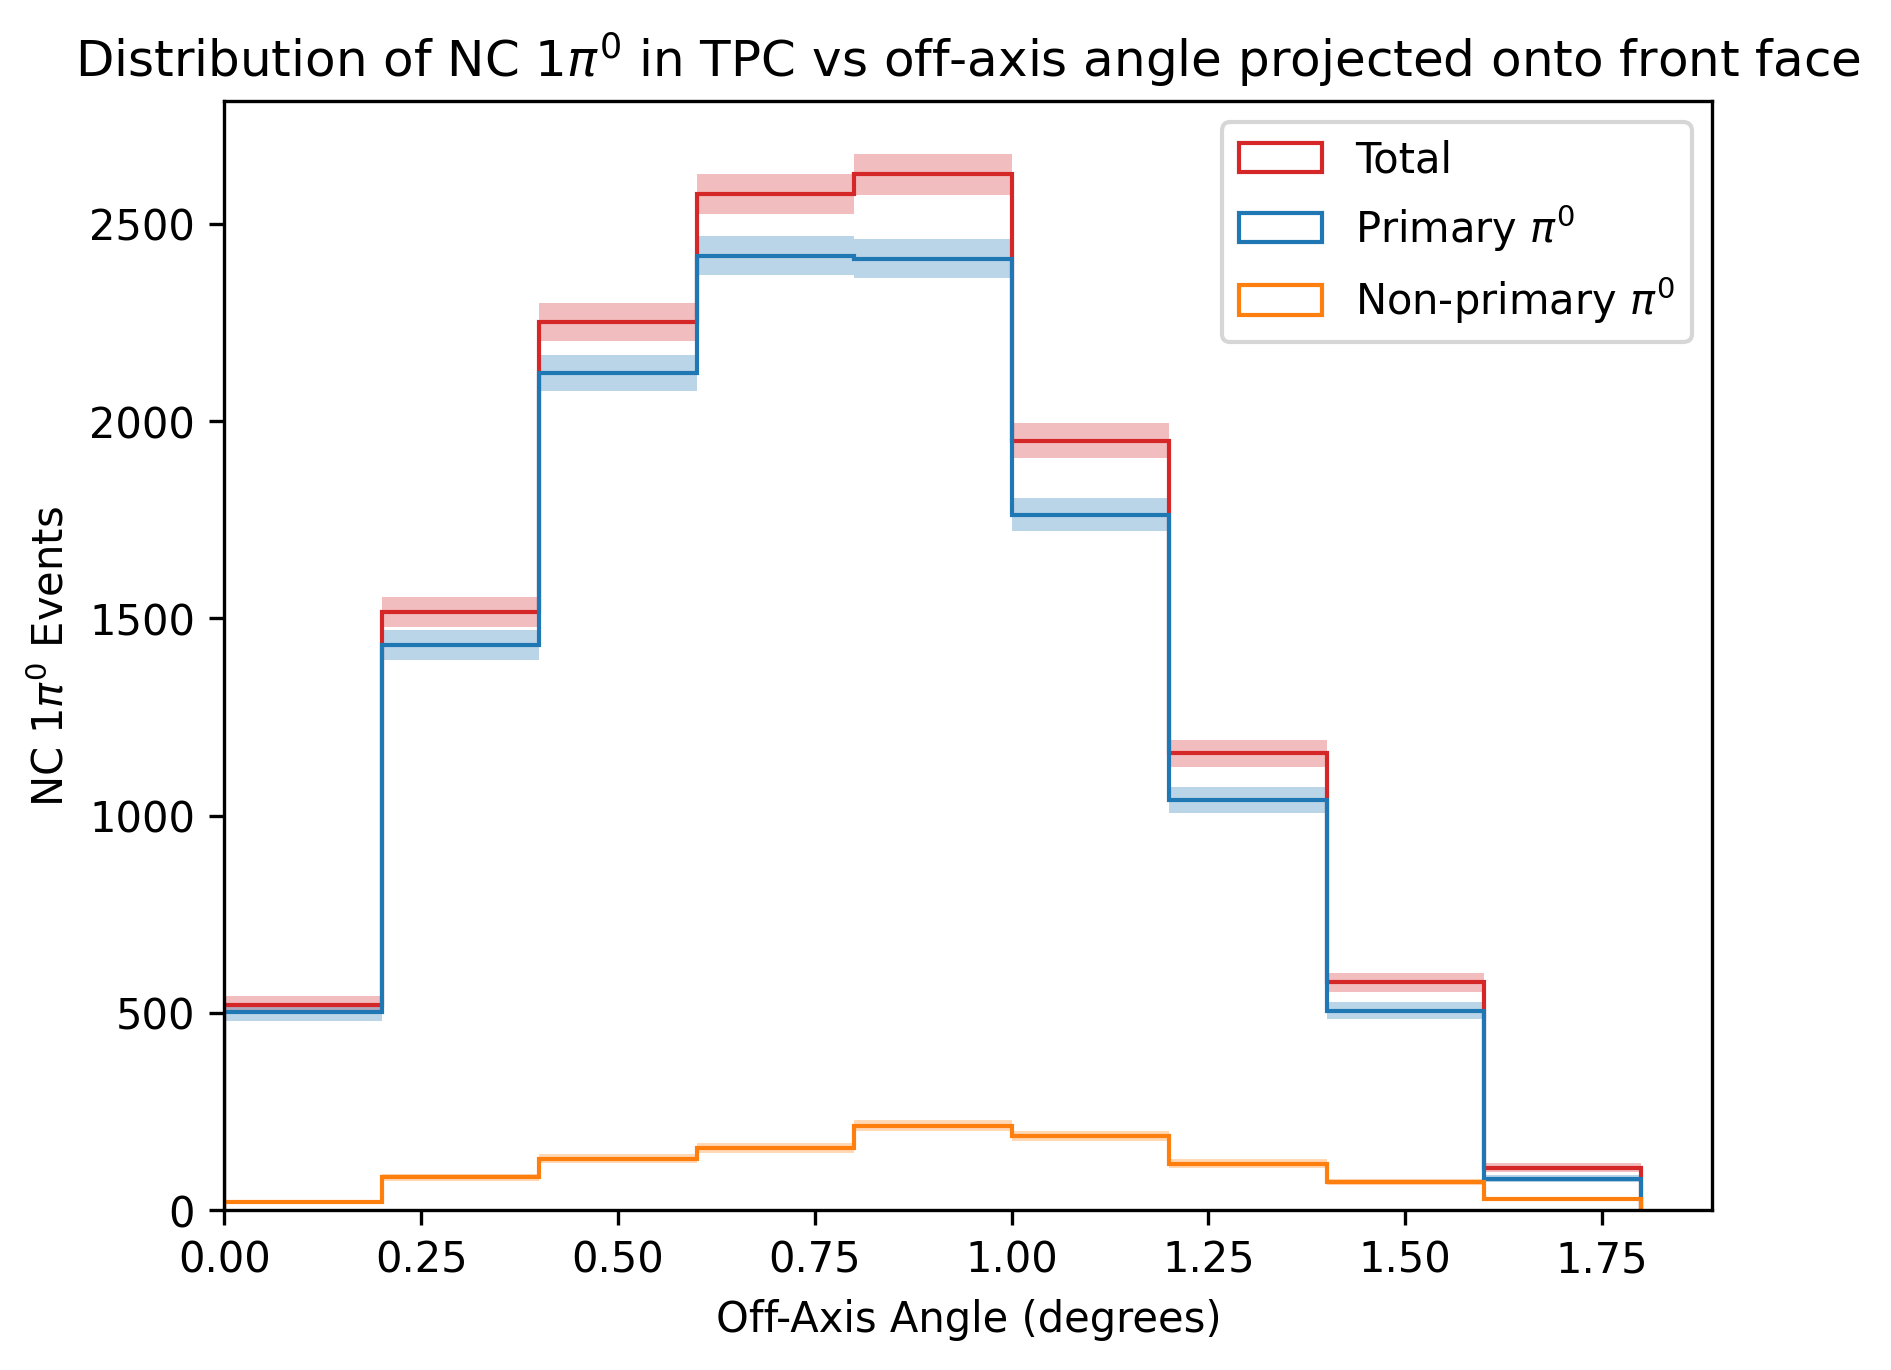

In [8]:
pi0_angles_tot = np.array([])
pi0_anglesP = np.array([])
pi0_anglesNP = np.array([])
for idx, row in df[df['is_NC'] & df["is_1pi0"]].iterrows():
    if len(row['pi0_angle_front']) > 0:
        for k in range(len(row['pi0_angle_front'])):
            if row['in_TPC_g4'][k]:
                pi0_angles_tot = np.append(pi0_angles_tot, row['pi0_angle_front'][k])
                if k == 0:
                    pi0_anglesP = np.append(pi0_anglesP, row['pi0_angle_front'][k])
                else:
                    pi0_anglesNP = np.append(pi0_anglesNP, row['pi0_angle_front'][k])
        
plt.figure(dpi=300)
counts, bins, _ = plt.hist(pi0_angles_tot, bins=nbinsTPC, histtype='step')
cP, bP, _ = plt.hist(pi0_anglesP, bins=bins, histtype='step')
cNP, bNP, _ = plt.hist(pi0_anglesNP, bins=bins, histtype='step')
wide = np.diff(bins)
norm_counts = counts
ncP = cP
ncNP = cNP
plt.clf()  # clear the previous plot
bin_centers = 0.5 * (bins[:-1] + bins[1:])
errors = np.sqrt(counts)
errP = np.sqrt(cP)
errNP = np.sqrt(cNP)
plt.bar(bin_centers, 2*errors, width=wide, bottom=norm_counts-errors, color=colorTot, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=norm_counts, histtype='step', color=colorTot, label='Total')
plt.bar(bin_centers, 2*errP, width=wide, bottom=ncP-errP, color=colorP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=ncP, histtype='step', color=colorP, label='Primary $\pi^0$')
plt.bar(bin_centers, 2*errNP, width=wide, bottom=ncNP-errNP, color=colorNP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=ncNP, histtype='step', color=colorNP, label='Non-primary $\pi^0$')
plt.title('Distribution of NC $1\pi^0$ in TPC vs off-axis angle projected onto front face')
plt.xlabel('Off-Axis Angle (degrees)')
plt.ylabel('NC $1\pi^0$ Events')
plt.ylim(*ylimit)
plt.xlim(*xlimit)
plt.legend()
plt.show()

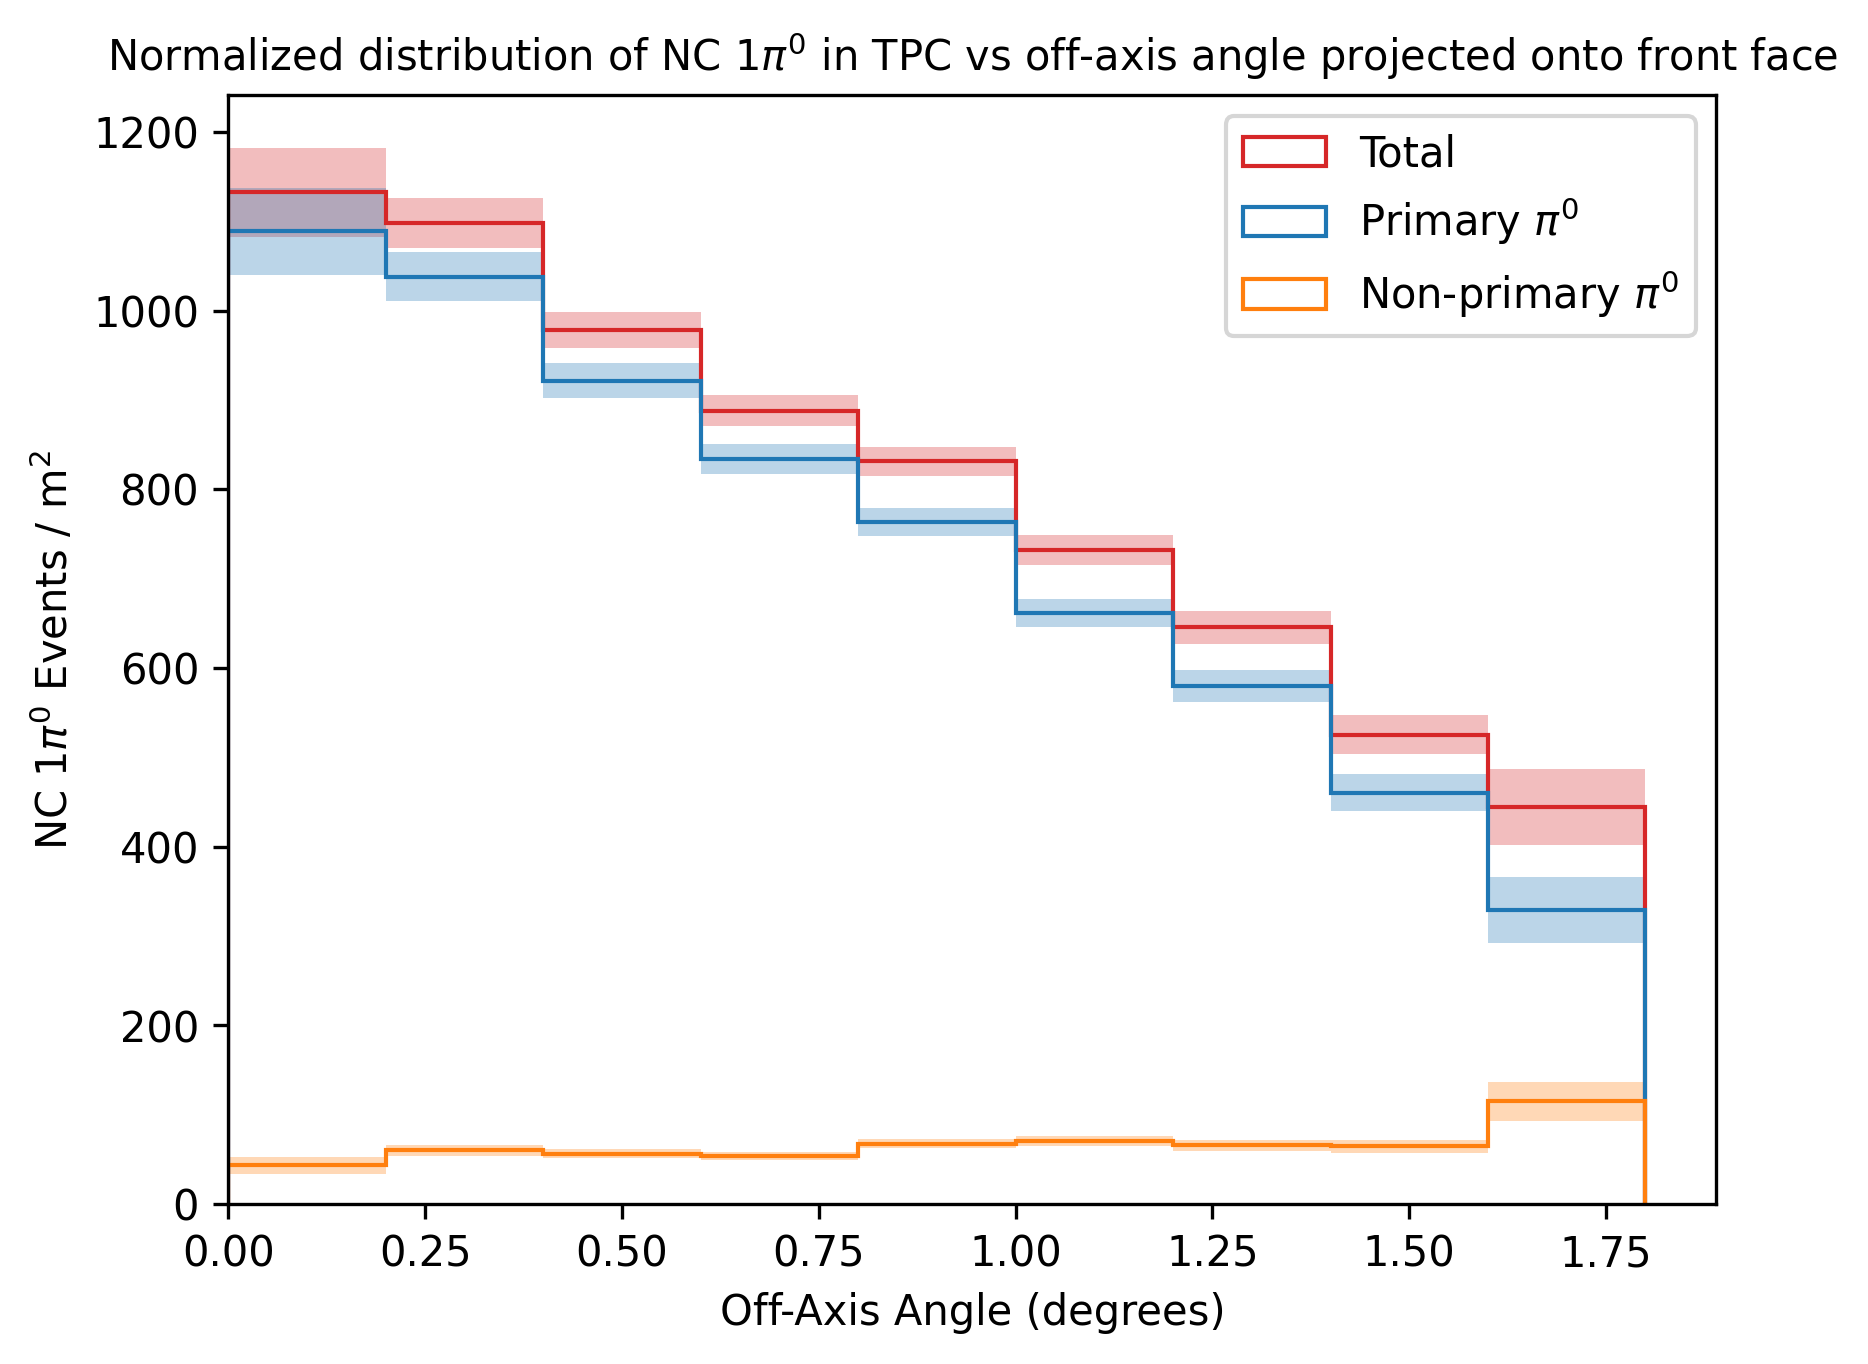

69.78080193731435


In [9]:
pi0_angles_tot = np.array([])
pi0_anglesP = np.array([])
pi0_anglesNP = np.array([])
for idx, row in df[df['is_NC'] & df["is_1pi0"]].iterrows():
    if len(row['pi0_angle_front']) > 0:
        for k in range(len(row['pi0_angle_front'])):
            if row['in_TPC_g4'][k]:
                pi0_angles_tot = np.append(pi0_angles_tot, row['pi0_angle_front'][k])
                if k == 0:
                    pi0_anglesP = np.append(pi0_anglesP, row['pi0_angle_front'][k])
                else:
                    pi0_anglesNP = np.append(pi0_anglesNP, row['pi0_angle_front'][k])
        
plt.figure(dpi=300)
counts, bins, _ = plt.hist(pi0_angles_tot, bins=nbinsTPC, histtype='step')
cP, bP, _ = plt.hist(pi0_anglesP, bins=bins, histtype='step')
cNP, bNP, _ = plt.hist(pi0_anglesNP, bins=bins, histtype='step')
wide = np.diff(bins)
norm_counts = counts / norm_areas
ncP = cP / norm_areas
ncNP = cNP / norm_areas
plt.clf()  # clear the previous plot
bin_centers = 0.5 * (bins[:-1] + bins[1:])
errors = np.sqrt(counts) / norm_areas
errP = np.sqrt(cP) / norm_areas
errNP = np.sqrt(cNP) / norm_areas
plt.bar(bin_centers, 2*errors, width=wide, bottom=norm_counts-errors, color=colorTot, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=norm_counts, histtype='step', color=colorTot, label='Total')
plt.bar(bin_centers, 2*errP, width=wide, bottom=ncP-errP, color=colorP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=ncP, histtype='step', color=colorP, label='Primary $\pi^0$')
plt.bar(bin_centers, 2*errNP, width=wide, bottom=ncNP-errNP, color=colorNP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=ncNP, histtype='step', color=colorNP, label='Non-primary $\pi^0$')
plt.title('Normalized distribution of NC $1\pi^0$ in TPC vs off-axis angle projected onto front face', fontsize=10)
plt.xlabel('Off-Axis Angle (degrees)')
plt.ylabel('NC $1\pi^0$ Events / m$^2$')
plt.ylim(*ylimit)
plt.xlim(*xlimit)
plt.legend()
plt.show()

percentDrop = (ncP[0] - ncP[-1]) / ncP[0] * 100
print(percentDrop)

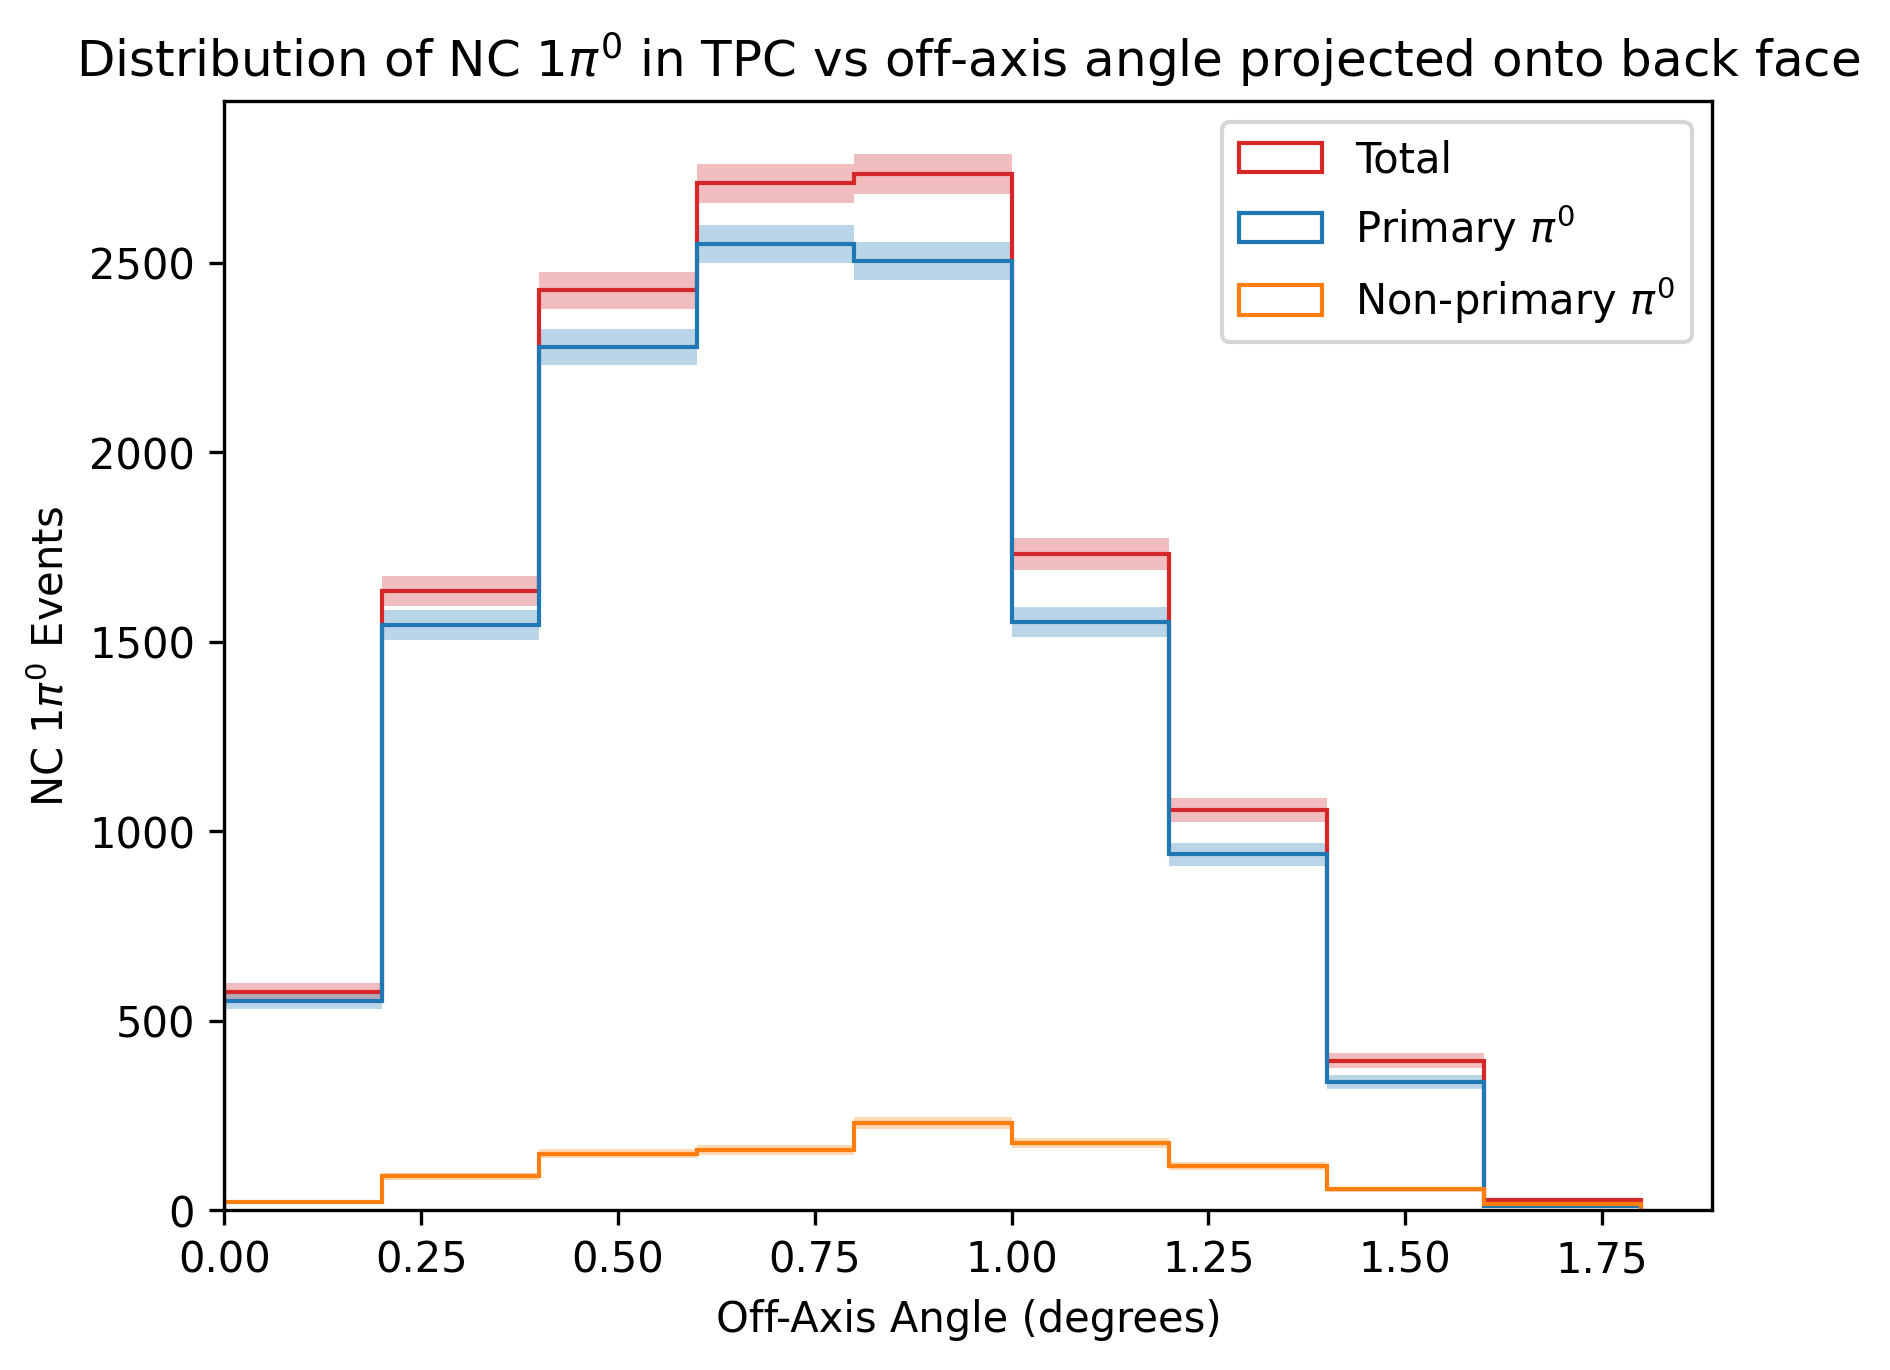

In [10]:
pi0_angles_tot = np.array([])
pi0_anglesP = np.array([])
pi0_anglesNP = np.array([])
for idx, row in df[df['is_NC'] & df["is_1pi0"]].iterrows():
    if len(row['pi0_angle_back']) > 0:
        for k in range(len(row['pi0_angle_back'])):
            if row['in_TPC_g4'][k]:
                pi0_angles_tot = np.append(pi0_angles_tot, row['pi0_angle_back'][k])
                if k == 0:
                    pi0_anglesP = np.append(pi0_anglesP, row['pi0_angle_back'][k])
                else:
                    pi0_anglesNP = np.append(pi0_anglesNP, row['pi0_angle_back'][k])
        
plt.figure(dpi=300)
counts, bins, _ = plt.hist(pi0_angles_tot, bins=nbinsTPC, histtype='step')
cP, bP, _ = plt.hist(pi0_anglesP, bins=bins, histtype='step')
cNP, bNP, _ = plt.hist(pi0_anglesNP, bins=bins, histtype='step')
wide = np.diff(bins)
norm_counts = counts
ncP = cP
ncNP = cNP
plt.clf()  # clear the previous plot
bin_centers = 0.5 * (bins[:-1] + bins[1:])
errors = np.sqrt(counts)
errP = np.sqrt(cP)
errNP = np.sqrt(cNP)
plt.bar(bin_centers, 2*errors, width=wide, bottom=norm_counts-errors, color=colorTot, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=norm_counts, histtype='step', color=colorTot, label='Total')
plt.bar(bin_centers, 2*errP, width=wide, bottom=ncP-errP, color=colorP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=ncP, histtype='step', color=colorP, label='Primary $\pi^0$')
plt.bar(bin_centers, 2*errNP, width=wide, bottom=ncNP-errNP, color=colorNP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=ncNP, histtype='step', color=colorNP, label='Non-primary $\pi^0$')
plt.title('Distribution of NC $1\pi^0$ in TPC vs off-axis angle projected onto back face')
plt.xlabel('Off-Axis Angle (degrees)')
plt.ylabel('NC $1\pi^0$ Events')
plt.ylim(*ylimit)
plt.xlim(*xlimit)
plt.legend()
plt.show()

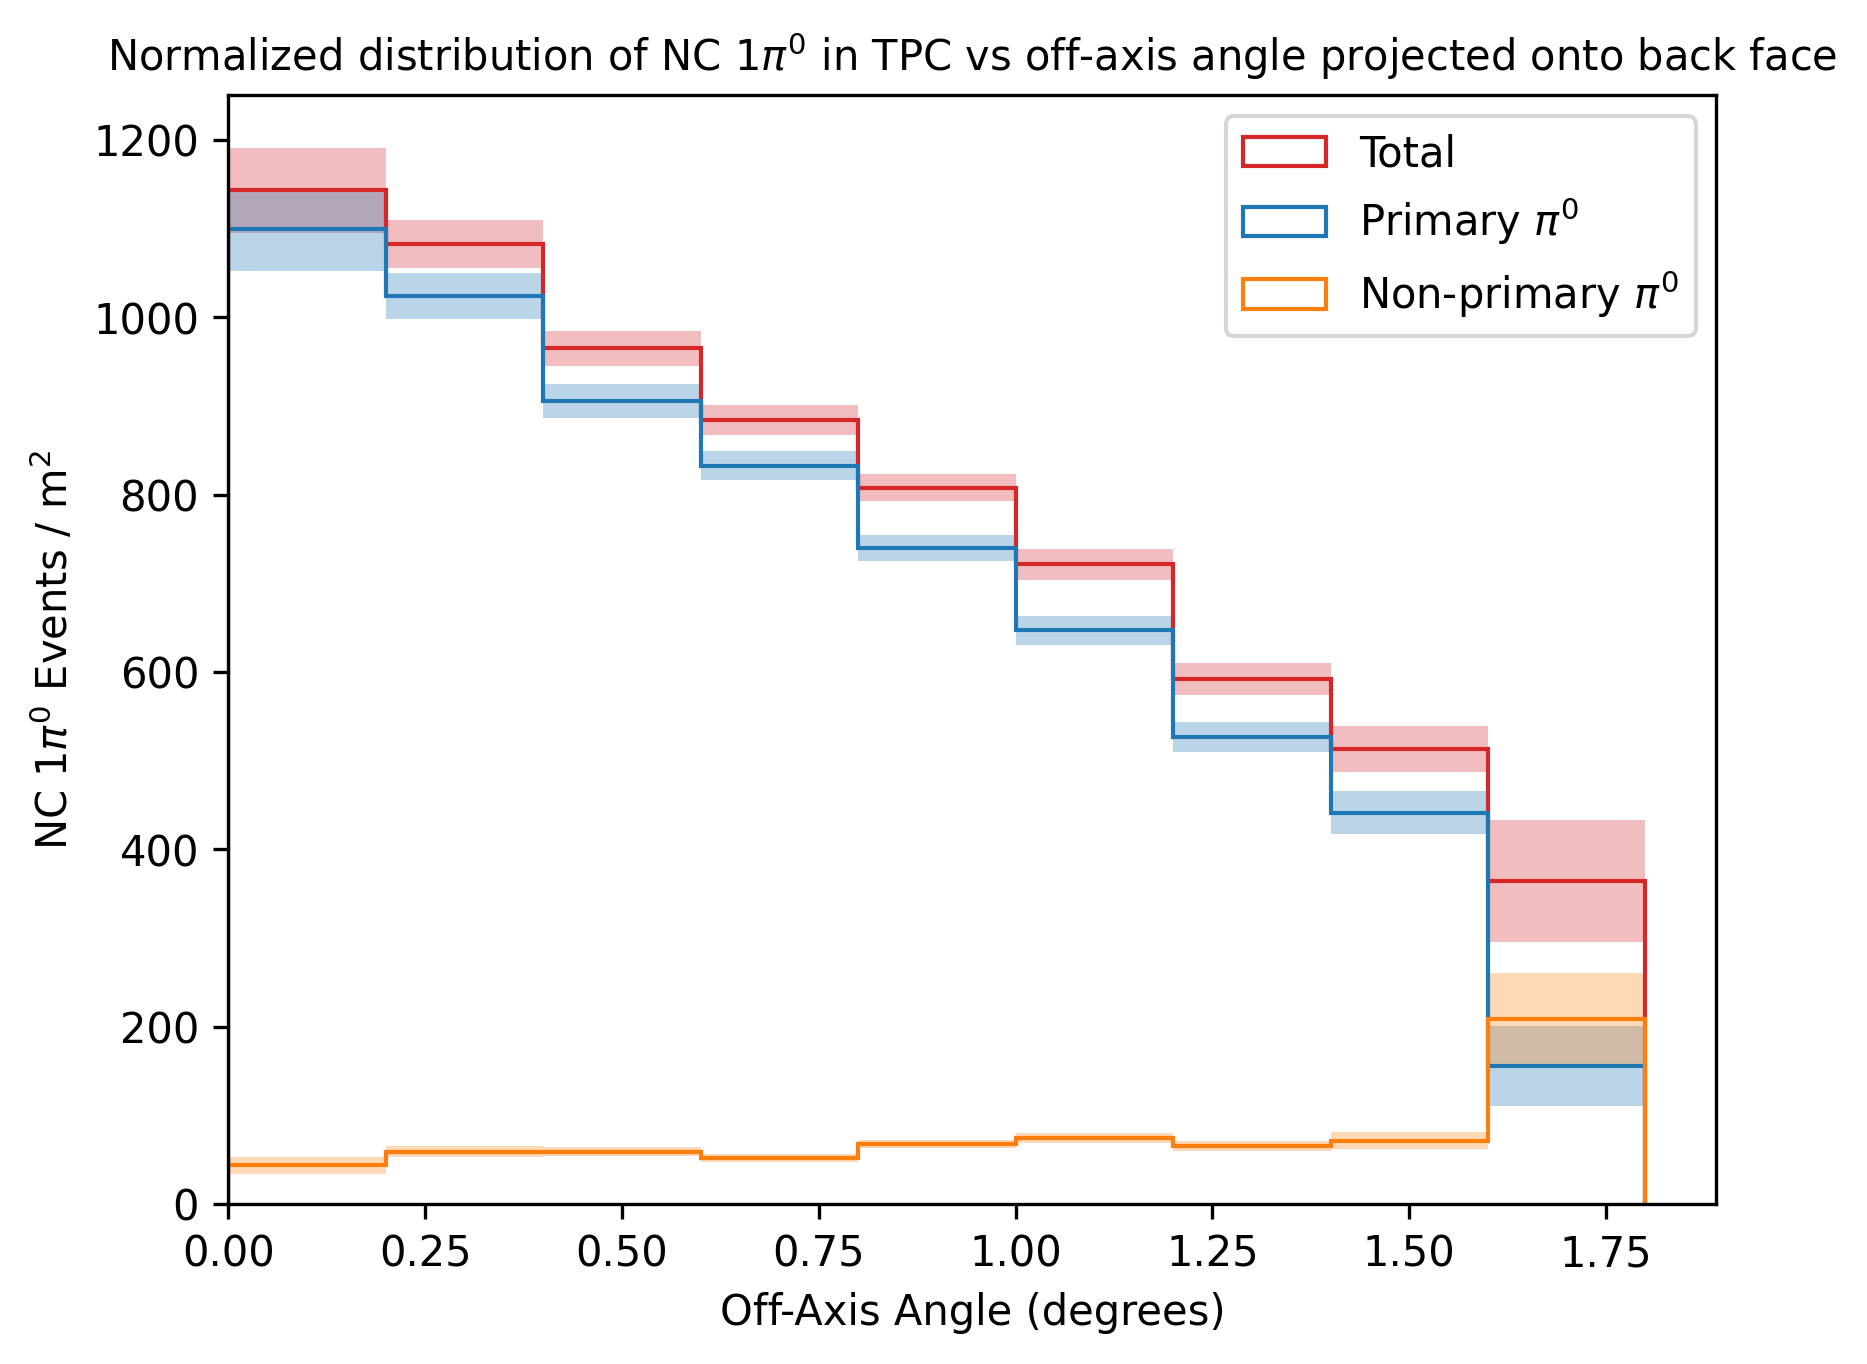

85.78393231634307


In [11]:
pi0_angles_tot = np.array([])
pi0_anglesP = np.array([])
pi0_anglesNP = np.array([])
for idx, row in df[df['is_NC'] & df["is_1pi0"]].iterrows():
    if len(row['pi0_angle_back']) > 0:
        for k in range(len(row['pi0_angle_back'])):
            if row['in_TPC_g4'][k]:
                pi0_angles_tot = np.append(pi0_angles_tot, row['pi0_angle_back'][k])
                if k == 0:
                    pi0_anglesP = np.append(pi0_anglesP, row['pi0_angle_back'][k])
                else:
                    pi0_anglesNP = np.append(pi0_anglesNP, row['pi0_angle_back'][k])
        
plt.figure(dpi=300)
counts, bins, _ = plt.hist(pi0_angles_tot, bins=nbinsTPC, histtype='step')
cP, bP, _ = plt.hist(pi0_anglesP, bins=bins, histtype='step')
cNP, bNP, _ = plt.hist(pi0_anglesNP, bins=bins, histtype='step')
wide = np.diff(bins)
norm_counts = counts / norm_areas_back
ncP = cP / norm_areas_back
ncNP = cNP / norm_areas_back
plt.clf()  # clear the previous plot
bin_centers = 0.5 * (bins[:-1] + bins[1:])
errors = np.sqrt(counts) / norm_areas_back
errP = np.sqrt(cP) / norm_areas_back
errNP = np.sqrt(cNP) / norm_areas_back
plt.bar(bin_centers, 2*errors, width=wide, bottom=norm_counts-errors, color=colorTot, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=norm_counts, histtype='step', color=colorTot, label='Total')
plt.bar(bin_centers, 2*errP, width=wide, bottom=ncP-errP, color=colorP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=ncP, histtype='step', color=colorP, label='Primary $\pi^0$')
plt.bar(bin_centers, 2*errNP, width=wide, bottom=ncNP-errNP, color=colorNP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=ncNP, histtype='step', color=colorNP, label='Non-primary $\pi^0$')
plt.title('Normalized distribution of NC $1\pi^0$ in TPC vs off-axis angle projected onto back face', fontsize=10)
plt.xlabel('Off-Axis Angle (degrees)')
plt.ylabel('NC $1\pi^0$ Events / m$^2$')
plt.ylim(*ylimit)
plt.xlim(*xlimit)
plt.legend()
plt.show()

percentDrop = (ncP[0] - ncP[-1]) / ncP[0] * 100
print(percentDrop)

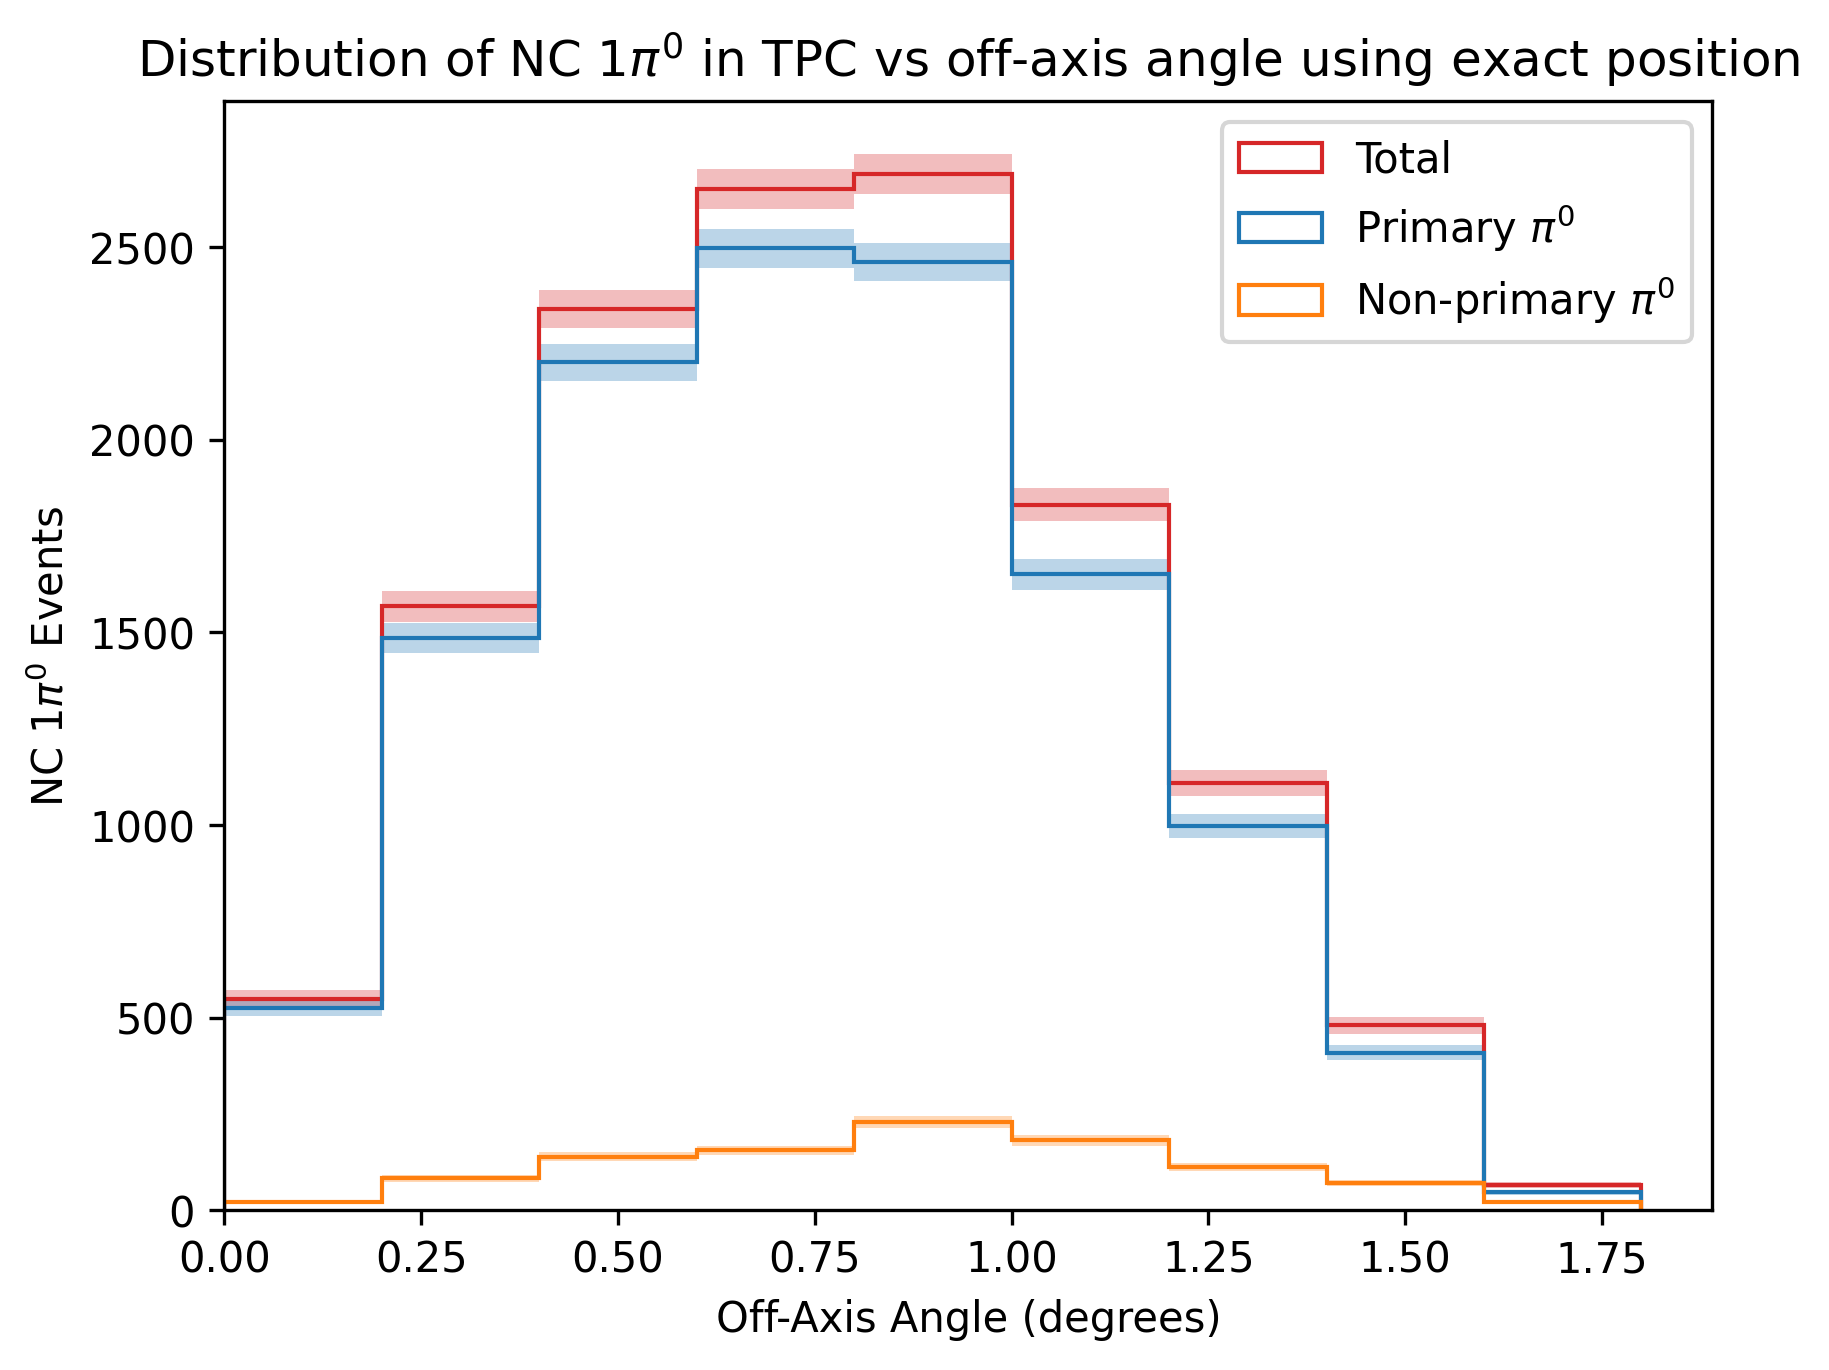

In [12]:
pi0_angles_tot = np.array([])
pi0_anglesP = np.array([])
pi0_anglesNP = np.array([])
for idx, row in df[df['is_NC'] & df["is_1pi0"]].iterrows():
    if len(row['pi0_angle_exact']) > 0:
        for k in range(len(row['pi0_angle_exact'])):
            if row['in_TPC_g4'][k]:
                pi0_angles_tot = np.append(pi0_angles_tot, row['pi0_angle_exact'][k])
                if k == 0:
                    pi0_anglesP = np.append(pi0_anglesP, row['pi0_angle_exact'][k])
                else:
                    pi0_anglesNP = np.append(pi0_anglesNP, row['pi0_angle_exact'][k])
        
plt.figure(dpi=300)
counts, bins, _ = plt.hist(pi0_angles_tot, bins=nbinsTPC, histtype='step')
cP, bP, _ = plt.hist(pi0_anglesP, bins=bins, histtype='step')
cNP, bNP, _ = plt.hist(pi0_anglesNP, bins=bins, histtype='step')
wide = np.diff(bins)
norm_counts = counts
ncP = cP
ncNP = cNP
plt.clf()  # clear the previous plot
bin_centers = 0.5 * (bins[:-1] + bins[1:])
errors = np.sqrt(counts)
errP = np.sqrt(cP)
errNP = np.sqrt(cNP)
plt.bar(bin_centers, 2*errors, width=wide, bottom=norm_counts-errors, color=colorTot, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=norm_counts, histtype='step', color=colorTot, label='Total')
plt.bar(bin_centers, 2*errP, width=wide, bottom=ncP-errP, color=colorP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=ncP, histtype='step', color=colorP, label='Primary $\pi^0$')
plt.bar(bin_centers, 2*errNP, width=wide, bottom=ncNP-errNP, color=colorNP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=ncNP, histtype='step', color=colorNP, label='Non-primary $\pi^0$')
plt.title('Distribution of NC $1\pi^0$ in TPC vs off-axis angle using exact position')
plt.xlabel('Off-Axis Angle (degrees)')
plt.ylabel('NC $1\pi^0$ Events')
plt.ylim(*ylimit)
plt.xlim(*xlimit)
plt.legend()
plt.show()

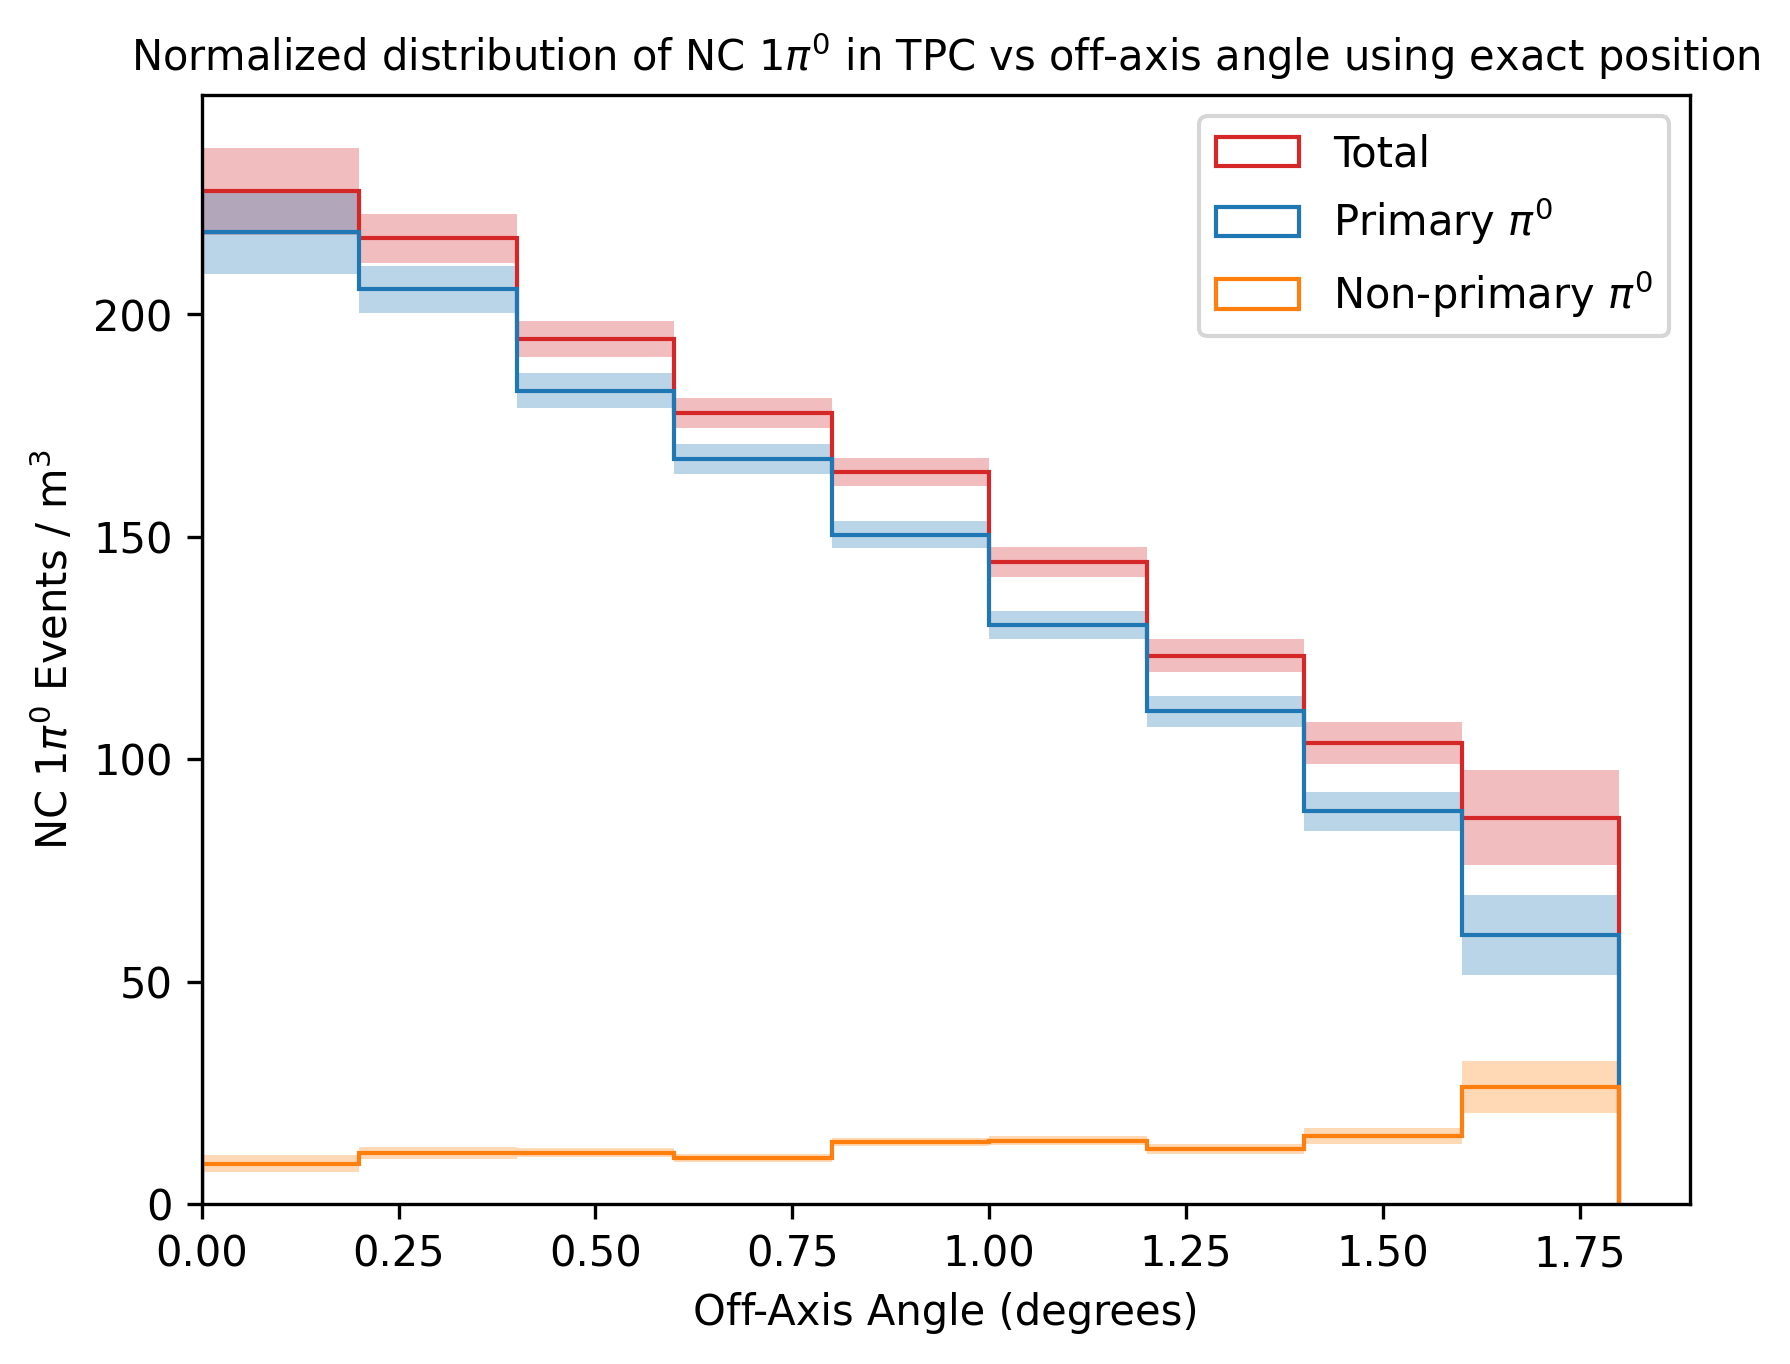

72.29088455992756


In [13]:
pi0_angles_tot = np.array([])
pi0_anglesP = np.array([])
pi0_anglesNP = np.array([])
for idx, row in df[df['is_NC'] & df["is_1pi0"]].iterrows():
    if len(row['pi0_angle_exact']) > 0:
        for k in range(len(row['pi0_angle_exact'])):
            if row['in_TPC_g4'][k]:
                pi0_angles_tot = np.append(pi0_angles_tot, row['pi0_angle_exact'][k])
                if k == 0:
                    pi0_anglesP = np.append(pi0_anglesP, row['pi0_angle_exact'][k])
                else:
                    pi0_anglesNP = np.append(pi0_anglesNP, row['pi0_angle_exact'][k])
        
plt.figure(dpi=300)
counts, bins, _ = plt.hist(pi0_angles_tot, bins=nbinsTPC, histtype='step')
cP, bP, _ = plt.hist(pi0_anglesP, bins=bins, histtype='step')
cNP, bNP, _ = plt.hist(pi0_anglesNP, bins=bins, histtype='step')
wide = np.diff(bins)
norm_counts = counts / norm_vols
ncP = cP / norm_vols
ncNP = cNP / norm_vols
plt.clf()  # clear the previous plot
bin_centers = 0.5 * (bins[:-1] + bins[1:])
errors = np.sqrt(counts) / norm_vols
errP = np.sqrt(cP) / norm_vols
errNP = np.sqrt(cNP) / norm_vols
plt.bar(bin_centers, 2*errors, width=wide, bottom=norm_counts-errors, color=colorTot, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=norm_counts, histtype='step', color=colorTot, label='Total')
plt.bar(bin_centers, 2*errP, width=wide, bottom=ncP-errP, color=colorP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=ncP, histtype='step', color=colorP, label='Primary $\pi^0$')
plt.bar(bin_centers, 2*errNP, width=wide, bottom=ncNP-errNP, color=colorNP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=ncNP, histtype='step', color=colorNP, label='Non-primary $\pi^0$')
plt.title('Normalized distribution of NC $1\pi^0$ in TPC vs off-axis angle using exact position', fontsize=10)
plt.xlabel('Off-Axis Angle (degrees)')
plt.ylabel('NC $1\pi^0$ Events / m$^3$')
plt.ylim(*ylimit)
plt.xlim(*xlimit)
plt.legend()
plt.show()

percentDrop = (ncP[0] - ncP[-1]) / ncP[0] * 100
print(percentDrop)